In [1]:
"""
Decision Tree Classifier - Iris Dataset
Covers: Training, Visualization, Pruning, Evaluation
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

## 1. LOAD & EXPLORE DATA

In [2]:
df = pd.read_csv("/content/1) iris.csv")

print("=" * 55)
print("         IRIS DATASET - DECISION TREE CLASSIFIER")
print("=" * 55)
print(f"\nShape        : {df.shape}")
print(f"Features     : {list(df.columns[:-1])}")
print(f"Target       : {df['species'].unique()}")
print(f"Class counts :\n{df['species'].value_counts().to_string()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

         IRIS DATASET - DECISION TREE CLASSIFIER

Shape        : (150, 5)
Features     : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Target       : ['setosa' 'versicolor' 'virginica']
Class counts :
species
setosa        50
versicolor    50
virginica     50

Missing values: 0


## 2. PREPARE DATA

In [3]:
X = df.drop("species", axis=1)
y = df["species"]

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f"\nTrain samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")


Train samples : 120
Test  samples : 30


## 3. TRAIN - UNPRUNED TREE

In [4]:
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

y_pred_full = dt_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)
f1_full  = f1_score(y_test, y_pred_full, average="weighted")

print("\n" + "─" * 55)
print("UNPRUNED TREE")
print(f"  Depth        : {dt_full.get_depth()}")
print(f"  Leaf nodes   : {dt_full.get_n_leaves()}")
print(f"  Accuracy     : {acc_full:.4f}")
print(f"  F1-Score     : {f1_full:.4f}")


───────────────────────────────────────────────────────
UNPRUNED TREE
  Depth        : 5
  Leaf nodes   : 8
  Accuracy     : 0.9333
  F1-Score     : 0.9333


## 4. PRUNING - find best max_depth via CV

In [5]:
depths = range(1, 10)
cv_scores = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="f1_weighted")
    cv_scores.append(scores.mean())

best_depth = list(depths)[np.argmax(cv_scores)]
print(f"\nBest depth (5-fold CV) : {best_depth}")


Best depth (5-fold CV) : 4


## 5. TRAIN - PRUNED TREE (cost-complexity + best depth)

In [6]:
# Cost-complexity pruning path
path = DecisionTreeClassifier(max_depth=best_depth, random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # exclude trivial root

# Pick best alpha via CV
alpha_scores = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(max_depth=best_depth, ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="f1_weighted")
    alpha_scores.append(scores.mean())

best_alpha = ccp_alphas[np.argmax(alpha_scores)] if len(ccp_alphas) > 0 else 0.0

dt_pruned = DecisionTreeClassifier(
    max_depth=best_depth,
    ccp_alpha=best_alpha,
    random_state=42
)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
acc_pruned = accuracy_score(y_test, y_pred_pruned)
f1_pruned  = f1_score(y_test, y_pred_pruned, average="weighted")

print("\n" + "─" * 55)
print("PRUNED TREE")
print(f"  Depth        : {dt_pruned.get_depth()}")
print(f"  Leaf nodes   : {dt_pruned.get_n_leaves()}")
print(f"  Best alpha   : {best_alpha:.4f}")
print(f"  Accuracy     : {acc_pruned:.4f}")
print(f"  F1-Score     : {f1_pruned:.4f}")


───────────────────────────────────────────────────────
PRUNED TREE
  Depth        : 4
  Leaf nodes   : 7
  Best alpha   : 0.0000
  Accuracy     : 0.9333
  F1-Score     : 0.9333


## 6. FULL CLASSIFICATION REPORT

In [7]:
print("\n" + "─" * 55)
print("PRUNED TREE - CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_pruned, target_names=class_names))


───────────────────────────────────────────────────────
PRUNED TREE - CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 7. VISUALIZATIONS  (4-panel figure)

Text(0.5, 0.985, 'Decision Tree Classifier  ·  Iris Dataset')

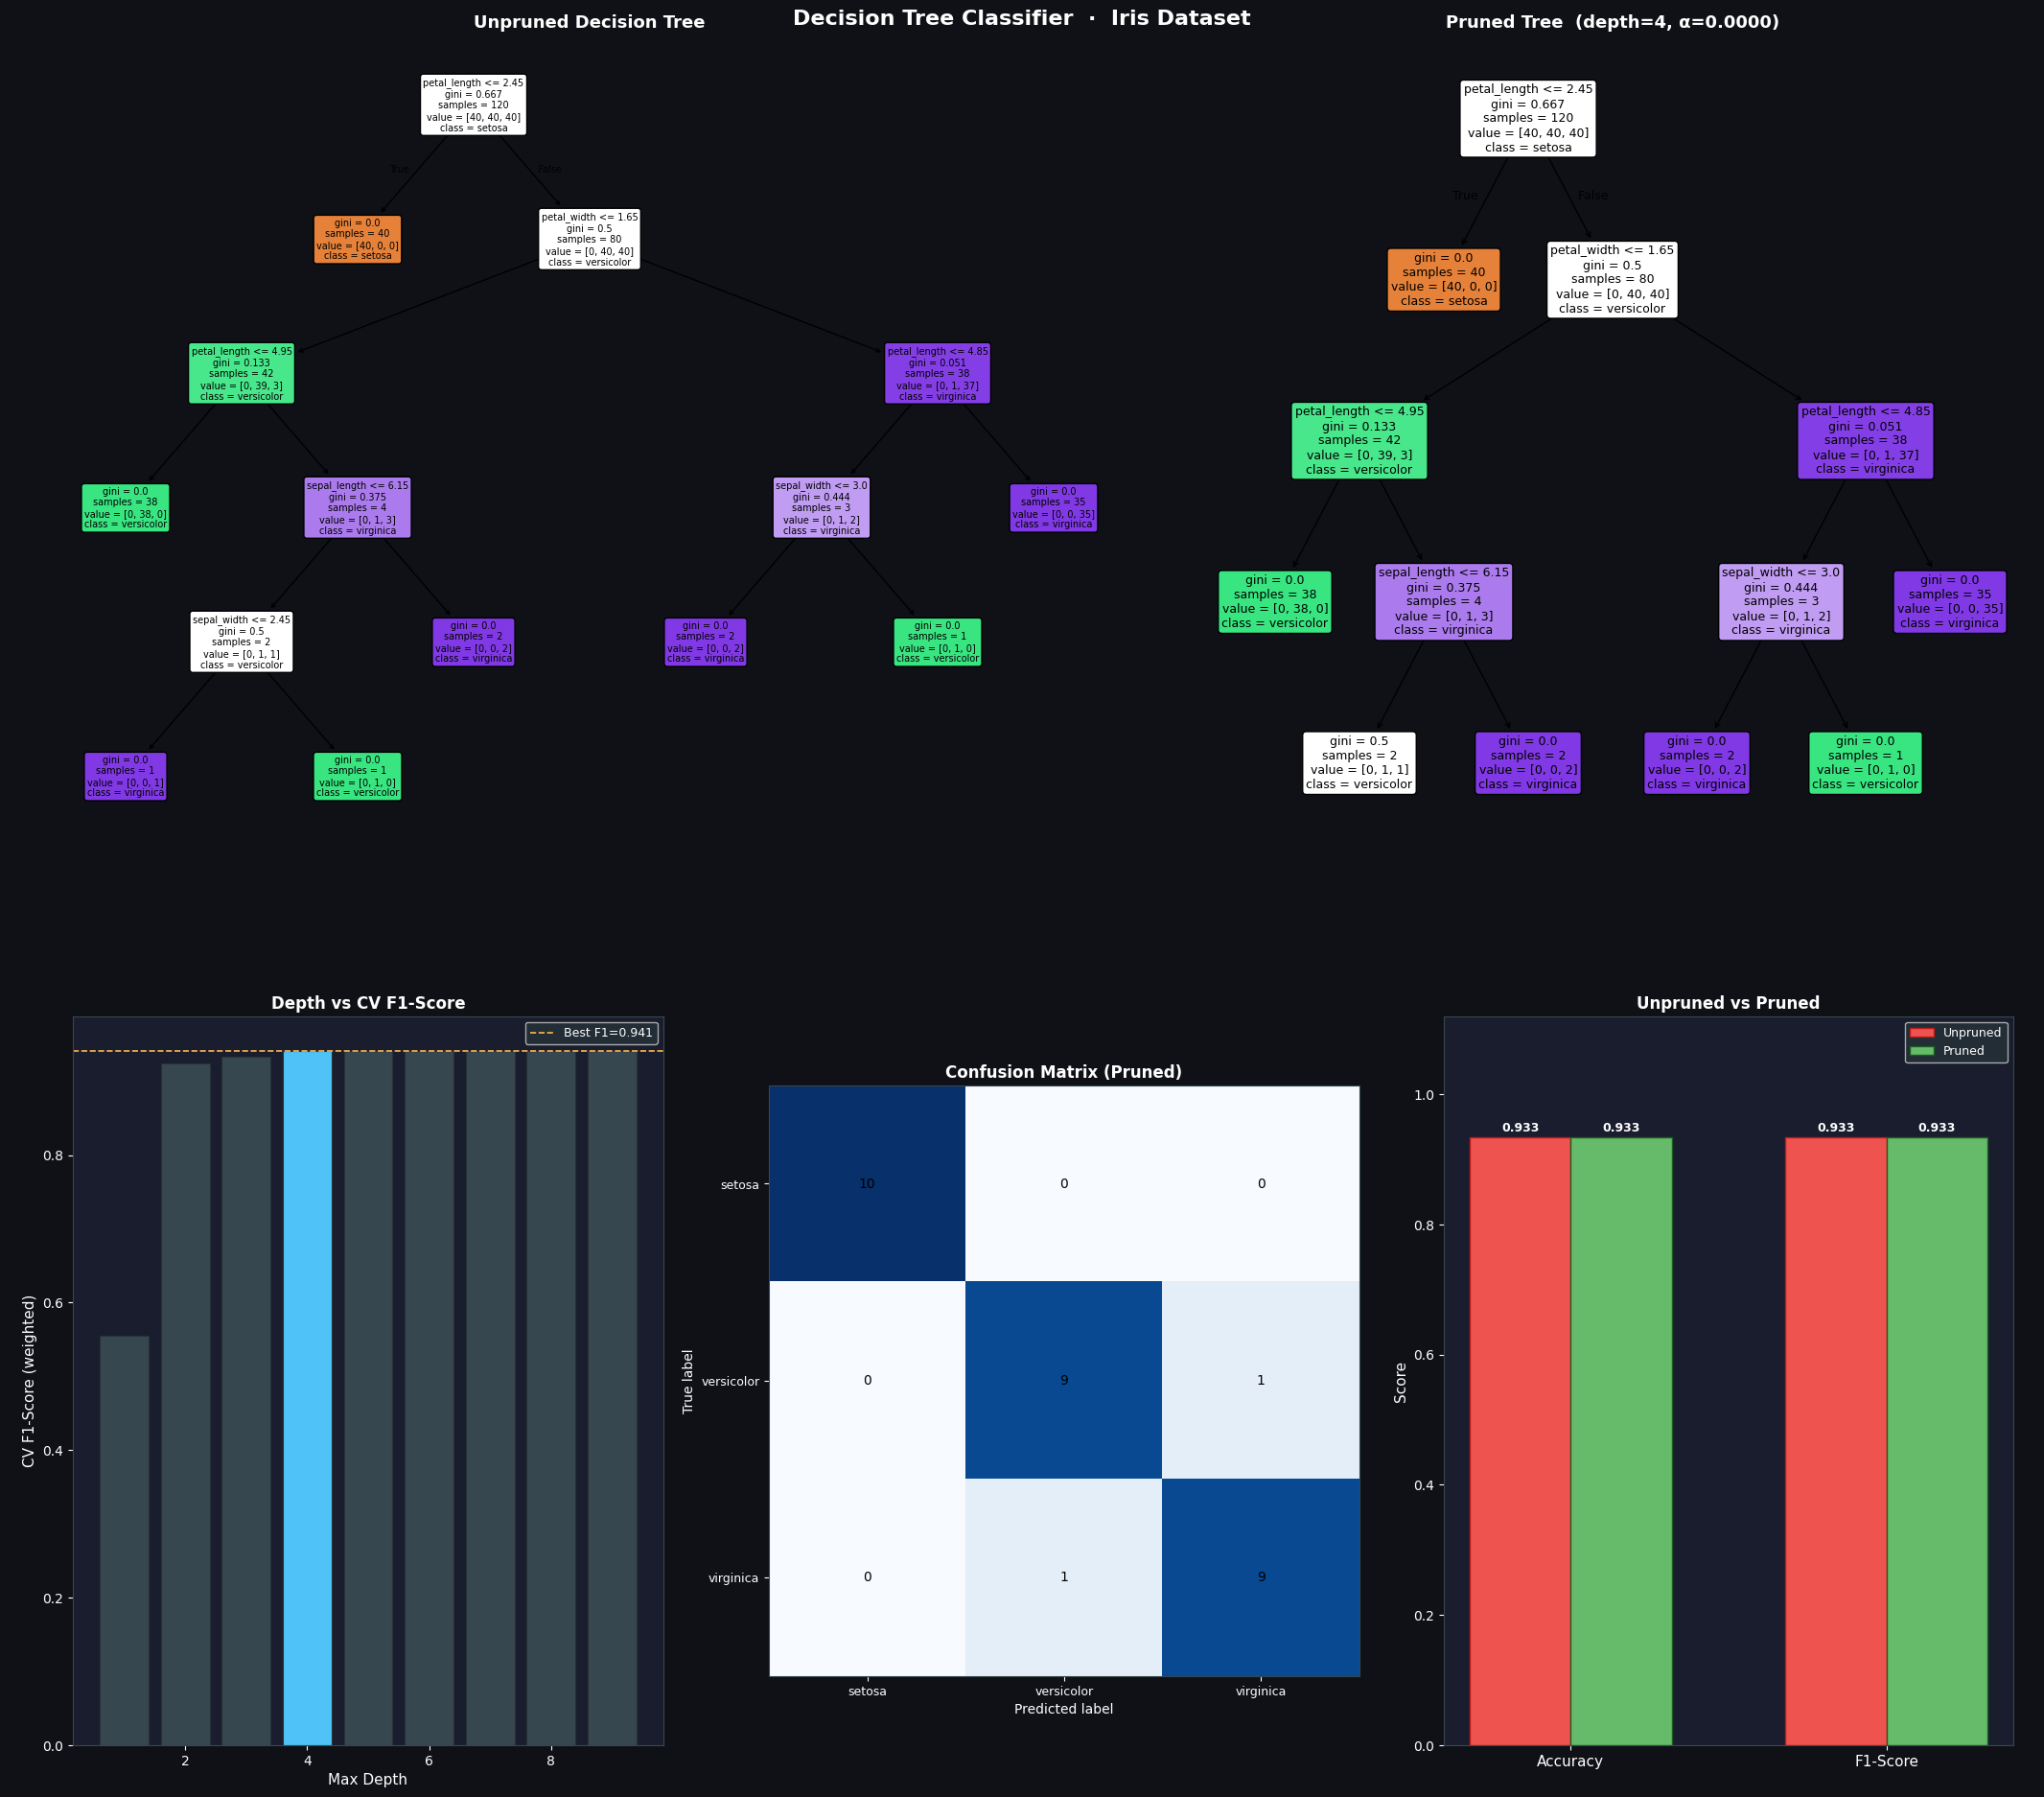

In [9]:
fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor("#0f1117")

COLORS = {"setosa": "#4fc3f7", "versicolor": "#81c784", "virginica": "#ffb74d"}
node_colors = [COLORS["setosa"], COLORS["versicolor"], COLORS["virginica"]]

# ── Panel A: Unpruned Tree ──────────────────
ax1 = fig.add_axes([0.02, 0.55, 0.55, 0.42])
ax1.set_facecolor("#1a1d2e")
plot_tree(
    dt_full, feature_names=X.columns.tolist(),
    class_names=class_names, filled=True,
    rounded=True, fontsize=7, ax=ax1,
    impurity=True, proportion=False
)
ax1.set_title("Unpruned Decision Tree", color="white", fontsize=13, fontweight="bold", pad=8)

# ── Panel B: Pruned Tree ───────────────────
ax2 = fig.add_axes([0.58, 0.55, 0.40, 0.42])
ax2.set_facecolor("#1a1d2e")
plot_tree(
    dt_pruned, feature_names=X.columns.tolist(),
    class_names=class_names, filled=True,
    rounded=True, fontsize=9, ax=ax2,
    impurity=True, proportion=False
)
ax2.set_title(
    f"Pruned Tree  (depth={best_depth}, α={best_alpha:.4f})",
    color="white", fontsize=13, fontweight="bold", pad=8
)

# ── Panel C: CV score vs depth ─────────────
ax3 = fig.add_axes([0.05, 0.08, 0.28, 0.38])
ax3.set_facecolor("#1a1d2e")
bars = ax3.bar(list(depths), cv_scores, color=[
    "#4fc3f7" if d == best_depth else "#37474f" for d in depths
], edgecolor="#263238", linewidth=0.8)
ax3.axhline(max(cv_scores), color="#ffb74d", linestyle="--", linewidth=1.2, label=f"Best F1={max(cv_scores):.3f}")
ax3.set_xlabel("Max Depth", color="white", fontsize=11)
ax3.set_ylabel("CV F1-Score (weighted)", color="white", fontsize=11)
ax3.set_title("Depth vs CV F1-Score", color="white", fontsize=12, fontweight="bold")
ax3.tick_params(colors="white")
ax3.spines[:].set_color("#37474f")
ax3.set_facecolor("#1a1d2e")
ax3.legend(fontsize=9, labelcolor="white", facecolor="#263238")

# ── Panel D: Confusion Matrix (Pruned) ────
ax4 = fig.add_axes([0.38, 0.08, 0.28, 0.38])
ax4.set_facecolor("#1a1d2e")
cm = confusion_matrix(y_test, y_pred_pruned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax4, colorbar=False, cmap="Blues")
ax4.set_title("Confusion Matrix (Pruned)", color="white", fontsize=12, fontweight="bold")
ax4.tick_params(colors="white", labelsize=9)
ax4.xaxis.label.set_color("white")
ax4.yaxis.label.set_color("white")
ax4.spines[:].set_color("#37474f")
for text in ax4.texts:
    text.set_color("black")

# ── Panel E: Metrics comparison bar ────────
ax5 = fig.add_axes([0.70, 0.08, 0.27, 0.38])
ax5.set_facecolor("#1a1d2e")
metrics = ["Accuracy", "F1-Score"]
full_vals   = [acc_full,   f1_full]
pruned_vals = [acc_pruned, f1_pruned]
x = np.arange(len(metrics))
w = 0.32
b1 = ax5.bar(x - w/2, full_vals,   w, label="Unpruned", color="#ef5350", edgecolor="#b71c1c")
b2 = ax5.bar(x + w/2, pruned_vals, w, label="Pruned",   color="#66bb6a", edgecolor="#1b5e20")
for bar in [*b1, *b2]:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom",
             color="white", fontsize=9, fontweight="bold")
ax5.set_xticks(x); ax5.set_xticklabels(metrics, color="white", fontsize=11)
ax5.set_ylim(0, 1.12)
ax5.set_ylabel("Score", color="white", fontsize=11)
ax5.set_title("Unpruned vs Pruned", color="white", fontsize=12, fontweight="bold")
ax5.tick_params(colors="white")
ax5.spines[:].set_color("#37474f")
ax5.legend(fontsize=9, labelcolor="white", facecolor="#263238")

fig.suptitle(
    "Decision Tree Classifier  ·  Iris Dataset",
    color="white", fontsize=16, fontweight="bold", y=0.985
)



## 8. TEXT REPRESENTATION OF PRUNED TREE

In [10]:
print("\n" + "─" * 55)
print("PRUNED TREE - TEXT STRUCTURE")
print(export_text(dt_pruned, feature_names=list(X.columns)))

print("=" * 55)
print("SUMMARY")
print(f"  Unpruned  →  depth={dt_full.get_depth()}, leaves={dt_full.get_n_leaves()}, acc={acc_full:.4f}, F1={f1_full:.4f}")
print(f"  Pruned    →  depth={dt_pruned.get_depth()}, leaves={dt_pruned.get_n_leaves()}, acc={acc_pruned:.4f}, F1={f1_pruned:.4f}")
print("=" * 55)


───────────────────────────────────────────────────────
PRUNED TREE - TEXT STRUCTURE
|--- petal_length <= 2.45
|   |--- class: 0
|--- petal_length >  2.45
|   |--- petal_width <= 1.65
|   |   |--- petal_length <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal_length >  4.95
|   |   |   |--- sepal_length <= 6.15
|   |   |   |   |--- class: 1
|   |   |   |--- sepal_length >  6.15
|   |   |   |   |--- class: 2
|   |--- petal_width >  1.65
|   |   |--- petal_length <= 4.85
|   |   |   |--- sepal_width <= 3.00
|   |   |   |   |--- class: 2
|   |   |   |--- sepal_width >  3.00
|   |   |   |   |--- class: 1
|   |   |--- petal_length >  4.85
|   |   |   |--- class: 2

SUMMARY
  Unpruned  →  depth=5, leaves=8, acc=0.9333, F1=0.9333
  Pruned    →  depth=4, leaves=7, acc=0.9333, F1=0.9333
